# Elo ratings data exploration and cleaning

## Introduction:
This notebook is about exploring the **Elo Ratings** dataset and cleaning it.

The process which will be followed during these notebook, is to first understand the data, explain it, understand its features and for what the dataset would help the project obejectives!After the data is understood and explained, the process will continue by cleaning the dataset, and prepare it for furute analyses and modeling.

The cleaning process is as follows:
- Get a first look at the data and understand it as it is possible
- Check for missing values
- Check for unlogical and invalid values such as outliers
- Check for duplicates (This also refers to invalid and unlogical values)
- Fix the data types (This mainly refers to the fixing of the highly incorrect and incompatible data types, e.g. int value in a str type column)
- Optimize the memory usage (This is about casting certain columns type to ones with sizes, which leads to the reduction of memory usage across the dataset!)
- Fix any text fields problems, including wrong encoding chars, white spaces etc!
- Remove useless columns
- Add more features if it will be useful enough and helpful to the next phases of the project
- Rename/Reorder the columns(if needed, for better clarity)
- Make some little analyses, visualizations and form assumptions (This is something which will be more detailly observed during the EDA project phase!)
- Store it into a file

Not everything in the plan above must be done.It is all up to the data how the cleaning process will develop and how the data will be handled!

Lets start:

#### What is the dataset about?
**As a offcial description of the dataset:** \
This dataset offers a simple entrance to the world of football match data analysis. It offers football match data from 27 countries and 42 leagues worldwide, including some of the best leagues such as the English Premier League, German Bundesliga, and Spanish La Liga. The data spans from the 2000/01 season to the most recent results from the 2024/25 season. The dataset also includes **Elo Ratings** for the given time period with snapshots of ~500 of the best teams in Europe

The data is devided into two datasets, each containg its specific information:
**1.EloRatings:**: \
This dataset is a collection of Elo ratings taken from Club Elo.The dataset represent teams, with their countries, divisions and the corresponding **elo ratings**.

**2.Matches**: \
This dataset provides match-level results and statistics.

**NOW THE IMPORTANT PART: WHAT IS AN ELO RATING**: \
An Elo rating in football represents a team’s **current**, most recent, numerical strength based on past results, designed to predict future performance. Unlike traditional league tables that only award points for a win, the Elo system uses a **sophisticated** formula that considers the **quality of the opponent, home field advantage, and the margin of victory** to determine a team's true skill level!

**Key Concepts of Football Elo:** \
**Relative Strength:**
Elo is not an absolute score; it is comparative. If Team A has a rating of 2000 and Team B has 1800, the 200-point difference allows for calculating the exact percentage likelihood of Team A winning.

**Predictive Accuracy:** Elo ratings are designed to be forward-looking. A higher rating indicates a higher probability of winning future matches, making it a popular tool for analysts and betting, with sites like ClubElo.com providing updated ratings.

**Self-Correction:** Ratings are updated after every match. If a high-rated team loses to a low-rated team (an upset), the high-rated team loses a significant number of points, and the low-rated team gains them, ensuring the ranking quickly reflects current form rather than historical reputation

**Factors Influencing the Rating:** \
Football Elo ratings are often adjusted for football-specific variables:

- **Result (W)**: A win, draw, or loss.
- **Match Status (K-factor):** Matches are weighted by importance.A World Cup knockout game affects the rating much more than a friendly match.
- **Goal Margin:** A win by 4 goals increases the rating more than a narrow 1-0 win.
- **Home Field Advantage:** The system adjusts for the increased probability of the home team winning.

One thing is very important here: \
**Recent form:**
- The recent from is something which has much more power than historical results and forms.This is something which the project will try to achive in the creation of the statistical models - adjusting the recent form to be much more influential than historial results.For such kind of models there is a specific definition: **Time-Dependent predictive models** - More on time-dependent statistical models on: [Statistical association football predictions](https://en.wikipedia.org/wiki/Statistical_association_football_predictions)

I think that it should have become a little bit clearer about what data will be dealing with this notebook and we are goot do go:

Now lets import the required libraries which will be needed for this notebook:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

from rapidfuzz import process, fuzz

from football_betting_analysis.config import START_SEASON, END_SEASON, ELO_RATINGS_INTERIM_PATH, LEAGUE_CODE_FD

from football_betting_analysis.data.text_cleaning import clean_text_values
from football_betting_analysis.data.save_data_into_file import save_data
from football_betting_analysis.data.data_cleaning import convert_string_to_datetime, validate_and_cast_dataframe_dtypes, optimize_dataframe_memory
from football_betting_analysis.data.team_match_validation import validate_team_matches
from football_betting_analysis.data.teams_names_mapper import build_team_mapping

## Data understanding and explantion:

Ok now lets load the datasets one by one and see that they contains. \
So lets start with the EloRatings dataset:

### Elo Ratings:

In [2]:
elo_ratings = pd.read_csv('../../data/raw/elo_ratings/EloRatings.csv')

In [3]:
elo_ratings

,date,club,country,elo
0,2000-07-01,Aachen,GER,1453.60
1,2000-07-01,Aalborg,DEN,1482.61
2,2000-07-01,Aalst,BEL,1337.53
3,2000-07-01,Aarhus,DEN,1381.46
4,2000-07-01,Aberdeen,SCO,1360.43
...,...,...,...,...
245028,2025-06-01,Wolfsburg,GER,1645.72
245029,2025-06-01,Wolves,ENG,1735.76
245030,2025-06-01,Zaragoza,ESP,1450.09
245031,2025-06-01,Zenit,RUS,1654.94


In [4]:
elo_ratings.shape

(245033, 4)

In [5]:
elo_ratings.columns

Index(['date', 'club', 'country', 'elo'], dtype='str')

## Missing values:

Lets see are there any missing values:

In [6]:
elo_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 245033 entries, 0 to 245032
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   date     245033 non-null  str    
 1   club     245033 non-null  str    
 2   country  245033 non-null  str    
 3   elo      245033 non-null  float64
dtypes: float64(1), str(3)
memory usage: 12.5 MB


Well, there are not any missing values.This is very good!

The dataset is really big and comprehensive.The first thing that I will do is to reduce it, **by taking only the elo ratings for the Spanish La Liga teams from season 2014 to 2025(2014/2015 to 2024/2025)**.None of the other teams are needed for me, just because the whole the project is about analysing the **Spanish La Liga**!

But before that lets make a copy of the dataset, so that we dont work with the raw data one:

In [7]:
elo_ratings_interim = elo_ratings.copy()

## Fixing the data types:

Now lets first see what types do we have:

In [8]:
elo_ratings_interim.dtypes

date           str
club           str
country        str
elo        float64
dtype: object

Everything except the date column, seems to be with the right type.

Lets fix the type of the date column to datetime, using the `convert_string_to_datetime` function!

In [9]:
elo_ratings_interim['date'] = convert_string_to_datetime(elo_ratings_interim['date'], '%Y-%m-%d')

In [10]:
elo_ratings_interim.dtypes

date       datetime64[us]
club                  str
country               str
elo               float64
dtype: object

## Limiting the size of the dataset:

This dataset contain data from seasons 2000 to 2025.For the purposes of my project and mainly because my other datasets require it, I am working only with seasons from 2014 to 2025 of the Spanish La Liga!

So I should reduce the dataset, by only getting the teams data from **1 of august(when a typical season starts) 2014 to 31 of may(when a typical season ends) 2025** of the Spanish La Liga!

> A typical football season starts in starts in August (month 8) and ends in May (month 5).

So lets limit the size of the dataset:

In [11]:
elo_ratings_interim = elo_ratings_interim[
    (elo_ratings_interim['date'] >= '2014-08-01') &
    (elo_ratings_interim['date'] <= '2025-05-31') &
    (elo_ratings_interim['country'] == 'ESP')
]

In [12]:
print(elo_ratings_interim['date'].min())
print(elo_ratings_interim['date'].max())

2014-08-01 00:00:00
2025-05-15 00:00:00


We have slightly reduced the size of the dataset(twice), and now everything is perfect!

## Adding additional features:

Now something which is very important for this dataset and for all of the others, at all, is the **season** feature, which this dataset is missing.So what I will do is that I will add this feature to the dataset.

To do so, I will just check if the date month of the entity is higher than 8(august), if so I will return the season in format `YYYY/YYYY+1`, if not I will return the season in format `YYYY/YYYY-1`

Lets do it:

In [13]:
elo_ratings_interim['season'] = np.where(
    elo_ratings_interim['date'].dt.month >= 8,
    elo_ratings_interim['date'].dt.year.astype(str) + '/' + (elo_ratings_interim['date'].dt.year + 1).astype(str),
    (elo_ratings_interim['date'].dt.year - 1).astype(str) + '/' + elo_ratings_interim['date'].dt.year.astype(str)
)

In [14]:
elo_ratings_interim

,date,club,country,elo,season
137806,2014-08-01,Alaves,ESP,1551.28,2014/2015
137807,2014-08-01,Albacete,ESP,1514.17,2014/2015
137808,2014-08-01,Alcorcon,ESP,1600.05,2014/2015
137809,2014-08-01,Almeria,ESP,1688.40,2014/2015
137821,2014-08-01,Ath Bilbao,ESP,1841.38,2014/2015
...,...,...,...,...,...
244598,2025-05-15,Valencia,ESP,1685.01,2024/2025
244600,2025-05-15,Valladolid,ESP,1482.18,2024/2025
244601,2025-05-15,Vallecano,ESP,1651.11,2024/2025
244609,2025-05-15,Villarreal,ESP,1769.85,2024/2025


Lets see if there is a mistake somewhere:

In [15]:
valid_seasons = [
    f"{year}/{year+1}" for year in range(START_SEASON, END_SEASON)
]

len(elo_ratings_interim[elo_ratings_interim['season'].isin(valid_seasons)]) == len(elo_ratings_interim)

True

Ok everything is correct and we are good to go!

## Renaming and Reordering the dataset:

Now something which will be very good to be done, is to rename the columns of the dataset and reorder it.This will either make him make it suitable for merging(with the other datasets) and also it will have clear and understandable structure!

So lets firts rename some of the columns:

In [16]:
elo_ratings_interim = elo_ratings_interim.rename(columns={'date': 'datetime', 'club': 'team_name', 'elo': 'team_elo_rating'})

In [17]:
elo_ratings_interim.columns

Index(['datetime', 'team_name', 'country', 'team_elo_rating', 'season'], dtype='str')

Now lets reorder its structure, just a little bit:

In [18]:
elo_ratings_interim = elo_ratings_interim[['country', 'season', 'datetime', 'team_name', 'team_elo_rating']]

In [19]:
elo_ratings_interim

,country,season,datetime,team_name,team_elo_rating
137806,ESP,2014/2015,2014-08-01,Alaves,1551.28
137807,ESP,2014/2015,2014-08-01,Albacete,1514.17
137808,ESP,2014/2015,2014-08-01,Alcorcon,1600.05
137809,ESP,2014/2015,2014-08-01,Almeria,1688.40
137821,ESP,2014/2015,2014-08-01,Ath Bilbao,1841.38
...,...,...,...,...,...
244598,ESP,2024/2025,2025-05-15,Valencia,1685.01
244600,ESP,2024/2025,2025-05-15,Valladolid,1482.18
244601,ESP,2024/2025,2025-05-15,Vallecano,1651.11
244609,ESP,2024/2025,2025-05-15,Villarreal,1769.85


## Reducing the dataset and cleaning irrelevant values from it:

Now, maybe the most important thing that should be done, as cleaning over this dataset, is that there should be removed all of the teams that are not in the Spanish first division(La Liga).The project is about only the teams of the Spanish La Liga.Everything else is **considered irrlevant** and it should be removed!

However, one problem in this dataset is that, it does not contain the teams exact divisions identifiers which will make it harder for me to get only what I want.So, in this situation I am required to get another dataset which contains matches data.What I will do is that I will separate the matches by seasons and I will get the unique La Liga 20 teams that have played in the season.

The process is:
- Get LA Liga matches data from season 2014 to 2025
- Separate the matches by season(e.g. 2014, 2015 etc)
- Get the unique 20 teams for each of the seasons
- Store their names
- Updating the dataset, so that at the end contains elo ratings only about the teams in the first Spanish division(La Liga)

Lets start: \
I will use the Understat matches dataset which is already cleaned and contains the excat data which we need:
So lets get it:

In [20]:
understat_matches = pd.read_parquet('../../data/interim/understat_data/interim_matches_v1.parquet')

In [21]:
understat_matches.head(3)

,datetime,season,h_id,h_title,a_id,a_title,goals_h,goals_a,xG_h,xG_a,prob_home_win,prob_draw,prob_away_win
id,,,,,,,,,,,,,
5826,2014-08-23 18:00:00,2014/2015,137,Malaga,147,Athletic Club,1,0,1.321070,1.141510,0.3996,0.3315,0.2689
5827,2014-08-23 20:00:00,2014/2015,138,Sevilla,146,Valencia,1,1,1.171970,1.749030,0.1984,0.2906,0.5110
5828,2014-08-23 20:00:00,2014/2015,155,Granada,139,Deportivo La Coruna,2,1,0.548351,0.379371,0.3244,0.4747,0.2009


An example of getting the 20 unique teams for season 2014 of the Spanish La Liga: 

In [22]:
season_teams = understat_matches[understat_matches['season'].str[:4] == str(2014)]['h_title'].unique()
season_teams

<ArrowStringArray>
[             'Malaga',             'Sevilla',             'Granada',
             'Almeria',               'Eibar',           'Barcelona',
          'Celta Vigo',             'Levante',         'Real Madrid',
      'Rayo Vallecano',              'Getafe',            'Valencia',
             'Cordoba',       'Athletic Club',     'Atletico Madrid',
            'Espanyol',          'Villarreal', 'Deportivo La Coruna',
       'Real Sociedad',               'Elche']
Length: 20, dtype: str

In [23]:
understat_all_teams = (
    understat_matches
        .groupby('season')['h_title']
            .unique()
            .to_dict()
)

In [24]:
understat_all_teams

{'2014/2015': <ArrowStringArray>
 [             'Malaga',             'Sevilla',             'Granada',
              'Almeria',               'Eibar',           'Barcelona',
           'Celta Vigo',             'Levante',         'Real Madrid',
       'Rayo Vallecano',              'Getafe',            'Valencia',
              'Cordoba',       'Athletic Club',     'Atletico Madrid',
             'Espanyol',          'Villarreal', 'Deportivo La Coruna',
        'Real Sociedad',               'Elche']
 Length: 20, dtype: str,
 '2015/2016': <ArrowStringArray>
 [             'Malaga', 'Deportivo La Coruna',            'Espanyol',
      'Atletico Madrid',      'Rayo Vallecano',       'Athletic Club',
       'Sporting Gijon',             'Levante',          'Real Betis',
              'Granada',          'Villarreal',       'Real Sociedad',
            'Barcelona',          'Celta Vigo',         'Real Madrid',
                'Eibar',             'Sevilla',            'Valencia',
         

Ok all of the required teams for each of the seasons are gotten!But now lets also get the names from the elo ratings dataset, because I have the feeling that the names will now be the same, which will lead to further problems and more processes required!

So lets see, the unique team names in the EloRatings dataset, for the seasons **2014 to 2025**:

In [25]:
elo_rating_all_teams = (
    elo_ratings_interim
        .groupby('season')['team_name']
            .unique()
            .to_dict()
)

In [26]:
elo_rating_all_teams

{'2014/2015': <ArrowStringArray>
 [      'Alaves',     'Albacete',     'Alcorcon',      'Almeria',
    'Ath Bilbao',   'Ath Madrid',    'Barcelona',  'Barcelona B',
         'Betis',        'Celta',      'Cordoba',        'Eibar',
         'Elche',      'Espanol',       'Getafe',       'Girona',
       'Granada',    'La Coruna',   'Las Palmas',      'Leganes',
       'Levante',   'Llagostera',         'Lugo',       'Malaga',
      'Mallorca',     'Mirandes',     'Numancia',      'Osasuna',
  'Ponferradina',  'Real Madrid',   'Recreativo',     'Sabadell',
     'Santander',      'Sevilla',     'Sociedad',     'Sp Gijon',
      'Tenerife',     'Valencia',   'Valladolid',    'Vallecano',
    'Villarreal',     'Zaragoza', 'Ath Bilbao B',       'Huesca',
        'Oviedo',    'Tarragona']
 Length: 46, dtype: str,
 '2015/2016': <ArrowStringArray>
 [       'Alaves',      'Albacete',      'Alcorcon',       'Almeria',
     'Ath Bilbao',  'Ath Bilbao B',    'Ath Madrid',     'Barcelona',
         

Mhh, as I have been thinking, the names in this dataset are not the same as the ones from the Understat data.What this means?Well, in order for me to exract only the right teams for each of the season, I will first need to fix the names of the EloRatings dataset so that they are the same as the ones from Understat.

I will do that by using an algorithm which simply first normalizes the names of the both sources and then uses a mapper which maps the wrong data names to the ones we want to get!

#### Except the ones from the first division(La Liga), there are others too, so we should keep that in mind! 

## Mapping different datasets names:

Now lets start with the creation of the alforithm. \
First I need to create the normalize function:

In [27]:
def normalize(text: str) -> str:
    """Normalize text for matching (NOT for output)."""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()    
    return text

Now something which is very important, and which is required for the alforithm to work properly is a mapping ALIASES dictionary.This dictionary will be used for team names which are just different and cannot be detected by the alforithm, and they should be handled manualy!

This is for the most specific cases, which in the algorithm will be with highest **priority** - the more specific ones should be handled first.This is a rule! 

In [28]:
EXACT_ALIASES = {
    "ath bilbao": "Athletic Club",
    "ath madrid": "Atletico Madrid",
    "sp gijon": "Sporting Gijon"
}

This is the main algorithm, which uses the **rapidfuzz library**, so that a **fuzzy matching** to be performed in the algorithm.

**What is a fuzzy matching**? \
Fuzzy match is a data analysis technique that identifies non-identical items that are likely similar, such as "Jon Smith" vs. "John Smith". It uses algorithms to calculate similarity scores, overcoming spelling errors, abbreviations, and formatting inconsistencies. It is widely used for data cleaning, deduplication, and search algorithms!

The algorithm(mapping function) is expected to be used in other datasets too, so for that reason the mapping function is moved into a dedicated script `teams_names_mapper` with the function: `build_team_mapping` which is the actual algorithm.The algorithm is designed to accept a **normalize function**, which in the different cases can be different(That's why it is made as a parameter), the **source_names** - The invalid names, that will be renamed, the **target_names** - The valid names, that will be used to rename the source names, a **threshold** - The tolerance level, deciding the cutoff point between a "match" and a "non-match" when comparing the source_names and the target_names and an **aliases** dict, which if passed to the function, is with highest priority and checks for more specific cases with words completely different one from another.

For the algorithm implementation visit the following link: [build_team_mapping](../../src/football_betting_analysis/data/teams_names_mapper.py)

So lets use the algorithm.

First I will test the algorithm by validating the teams names in the two datasets from the season **2014/2015**:

In [29]:
mapping, unresolved = build_team_mapping(
    normalize=normalize, 
    source_names=elo_rating_all_teams['2014/2015'], 
    target_names=understat_all_teams['2014/2015'],
    aliases=EXACT_ALIASES)

mapping

{'Alaves': None,
 'Albacete': None,
 'Alcorcon': None,
 'Almeria': 'Almeria',
 'Ath Bilbao': 'Athletic Club',
 'Ath Madrid': 'Atletico Madrid',
 'Barcelona': 'Barcelona',
 'Betis': None,
 'Celta': 'Celta Vigo',
 'Cordoba': 'Cordoba',
 'Eibar': 'Eibar',
 'Elche': 'Elche',
 'Espanol': 'Espanyol',
 'Getafe': 'Getafe',
 'Girona': None,
 'Granada': 'Granada',
 'La Coruna': 'Deportivo La Coruna',
 'Las Palmas': None,
 'Leganes': None,
 'Levante': 'Levante',
 'Llagostera': None,
 'Lugo': None,
 'Malaga': 'Malaga',
 'Mallorca': None,
 'Mirandes': None,
 'Numancia': None,
 'Osasuna': None,
 'Ponferradina': None,
 'Real Madrid': 'Real Madrid',
 'Recreativo': None,
 'Sabadell': None,
 'Santander': None,
 'Sevilla': 'Sevilla',
 'Sociedad': 'Real Sociedad',
 'Sp Gijon': None,
 'Tenerife': None,
 'Valencia': 'Valencia',
 'Valladolid': None,
 'Vallecano': 'Rayo Vallecano',
 'Villarreal': 'Villarreal',
 'Zaragoza': None,
 'Huesca': None,
 'Oviedo': None,
 'Tarragona': None}

Well we can see that many of them are none, and this is because they are not from the first Spanish division(La Liga), but from lowest divisions.And yes we should remove them, because we don't care about them!

But first lets see the ones which are note None, as we expect these to be the 20 valid first division teams with keys: the original invalid names and with values: the new valid target names! 

In [30]:
result = {k: v for k, v in mapping.items() if v is not None}

result

{'Almeria': 'Almeria',
 'Ath Bilbao': 'Athletic Club',
 'Ath Madrid': 'Atletico Madrid',
 'Barcelona': 'Barcelona',
 'Celta': 'Celta Vigo',
 'Cordoba': 'Cordoba',
 'Eibar': 'Eibar',
 'Elche': 'Elche',
 'Espanol': 'Espanyol',
 'Getafe': 'Getafe',
 'Granada': 'Granada',
 'La Coruna': 'Deportivo La Coruna',
 'Levante': 'Levante',
 'Malaga': 'Malaga',
 'Real Madrid': 'Real Madrid',
 'Sevilla': 'Sevilla',
 'Sociedad': 'Real Sociedad',
 'Valencia': 'Valencia',
 'Vallecano': 'Rayo Vallecano',
 'Villarreal': 'Villarreal'}

Now as we have used the teams names from season 2014 for both source and target names, lets check if the results above actually matche with the ones from the understat dataset(the target valid names)!

I will do that by simply check if values of the dict result above, are existing in the understat target names list:

In [31]:
counter = 0
for key, value in result.items():
    if value in understat_all_teams['2014/2015']:
        counter += 1
        
counter

20

Well there are 20 valid matching teams.This is good.But now to ensure that everything is working as expected I will do that for each of the seasons from 2014 to 2025.

In [32]:
seasons = [f"{str(year)}/{str(year+1)}" for year in range(START_SEASON, END_SEASON)]

valid_teams = {}
for season in seasons:
    season = str(season)
    source_names = elo_rating_all_teams[season]
    target_names = understat_all_teams[season]
    
    # These are the results from the mapping algorithm
    mapping, unresolved = build_team_mapping(
        normalize=normalize, 
        source_names=source_names, 
        target_names=target_names,
        aliases=EXACT_ALIASES)
    
    # Getting only the not None ones
    result = {k: v for k, v in mapping.items() if v is not None}
    
    print(f'{season}: {unresolved}')
    
    counter = 0
    for key, value in result.items():
        if value in understat_all_teams[season]:
            counter += 1
            
    valid_teams[season] = counter

2014/2015: ['Alaves', 'Albacete', 'Alcorcon', 'Betis', 'Girona', 'Las Palmas', 'Leganes', 'Llagostera', 'Lugo', 'Mallorca', 'Mirandes', 'Numancia', 'Osasuna', 'Ponferradina', 'Recreativo', 'Sabadell', 'Santander', 'Sp Gijon', 'Tenerife', 'Valladolid', 'Zaragoza', 'Huesca', 'Oviedo', 'Tarragona']
2015/2016: ['Alaves', 'Albacete', 'Alcorcon', 'Almeria', 'Cordoba', 'Elche', 'Girona', 'Huesca', 'Leganes', 'Llagostera', 'Lugo', 'Mallorca', 'Mirandes', 'Numancia', 'Osasuna', 'Oviedo', 'Ponferradina', 'Tarragona', 'Tenerife', 'Valladolid', 'Zaragoza', 'Cadiz', 'Reus Deportiu', 'UCAM Murcia']
2016/2017: ['Alcorcon', 'Almeria', 'Cadiz', 'Cordoba', 'Elche', 'Getafe', 'Girona', 'Huesca', 'Levante', 'Lugo', 'Mallorca', 'Mirandes', 'Numancia', 'Oviedo', 'Reus Deportiu', 'Tarragona', 'Tenerife', 'UCAM Murcia', 'Valladolid', 'Vallecano', 'Zaragoza', 'Albacete', 'Leonesa', 'Lorca']
2017/2018: ['Albacete', 'Alcorcon', 'Almeria', 'Cadiz', 'Cordoba', 'Granada', 'Huesca', 'Leonesa', 'Lorca', 'Lugo', 'Numa

In [33]:
valid_teams

{'2014/2015': 20,
 '2015/2016': 20,
 '2016/2017': 20,
 '2017/2018': 20,
 '2018/2019': 20,
 '2019/2020': 20,
 '2020/2021': 20,
 '2021/2022': 20,
 '2022/2023': 20,
 '2023/2024': 20,
 '2024/2025': 20}

We can clearly see that there are 20 unique teams for each of the season with valid names!

## Applying the Mapping function to the Elo Ratings dataset:

So now as we have tested that algorithm that it is working, lets actually apply the algorithm to the elo ratings dataset and rename all of the invalid La Liga teams names:

In [34]:
df = elo_ratings_interim.copy()

In [35]:
elo_ratings_aliases = {
    "ath bilbao": "Athletic Club",
    "ath madrid": "Atletico Madrid",
    "sp gijon": "Sporting Gijon"
}

In [36]:
seasons = [f"{str(year)}/{str(year+1)}" for year in range(START_SEASON, END_SEASON)]
    
season_mappings = {}
season_unresolved = {}

for season in seasons:
    source_names = elo_rating_all_teams[season]
    target_names = understat_all_teams[season]

    mapping, unresolved = build_team_mapping(
        normalize=normalize,
        source_names=source_names,
        target_names=target_names,
        aliases=elo_ratings_aliases
    )

    season_mappings[season] = mapping
    season_unresolved[season] = unresolved

Now I should create a function which applies the mapping to the dataframe row by row using both season + club:

In [37]:
def map_team(row):
    season = row['season']
    team = row['team_name']

    mapping = season_mappings.get(season, {})

    return mapping.get(team, None)

Now lets finally apply the function:

In [38]:
df['club_clean'] = df.apply(map_team, axis=1)

In [39]:
df

,country,season,datetime,team_name,team_elo_rating,club_clean
137806,ESP,2014/2015,2014-08-01,Alaves,1551.28,NaN
137807,ESP,2014/2015,2014-08-01,Albacete,1514.17,NaN
137808,ESP,2014/2015,2014-08-01,Alcorcon,1600.05,NaN
137809,ESP,2014/2015,2014-08-01,Almeria,1688.40,Almeria
137821,ESP,2014/2015,2014-08-01,Ath Bilbao,1841.38,Athletic Club
...,...,...,...,...,...,...
244598,ESP,2024/2025,2025-05-15,Valencia,1685.01,Valencia
244600,ESP,2024/2025,2025-05-15,Valladolid,1482.18,Real Valladolid
244601,ESP,2024/2025,2025-05-15,Vallecano,1651.11,Rayo Vallecano
244609,ESP,2024/2025,2025-05-15,Villarreal,1769.85,Villarreal


There are many NaN values, and these are the values from the teams which are not in La Liga, so we should remove them:

In [40]:
df = df[df['club_clean'].notna()]

In [41]:
df

,country,season,datetime,team_name,team_elo_rating,club_clean
137809,ESP,2014/2015,2014-08-01,Almeria,1688.40,Almeria
137821,ESP,2014/2015,2014-08-01,Ath Bilbao,1841.38,Athletic Club
137822,ESP,2014/2015,2014-08-01,Ath Madrid,1975.84,Atletico Madrid
137831,ESP,2014/2015,2014-08-01,Barcelona,2024.80,Barcelona
137871,ESP,2014/2015,2014-08-01,Celta,1748.88,Celta Vigo
...,...,...,...,...,...,...
244555,ESP,2024/2025,2025-05-15,Sociedad,1666.20,Real Sociedad
244598,ESP,2024/2025,2025-05-15,Valencia,1685.01,Valencia
244600,ESP,2024/2025,2025-05-15,Valladolid,1482.18,Real Valladolid
244601,ESP,2024/2025,2025-05-15,Vallecano,1651.11,Rayo Vallecano


Now lets replace the original column and drop the helping one:

In [42]:
df['team_name'] = df['club_clean']

df = df.drop(columns='club_clean')

In [43]:
df

,country,season,datetime,team_name,team_elo_rating
137809,ESP,2014/2015,2014-08-01,Almeria,1688.40
137821,ESP,2014/2015,2014-08-01,Athletic Club,1841.38
137822,ESP,2014/2015,2014-08-01,Atletico Madrid,1975.84
137831,ESP,2014/2015,2014-08-01,Barcelona,2024.80
137871,ESP,2014/2015,2014-08-01,Celta Vigo,1748.88
...,...,...,...,...,...
244555,ESP,2024/2025,2025-05-15,Real Sociedad,1666.20
244598,ESP,2024/2025,2025-05-15,Valencia,1685.01
244600,ESP,2024/2025,2025-05-15,Real Valladolid,1482.18
244601,ESP,2024/2025,2025-05-15,Rayo Vallecano,1651.11


Now lets see if there are 20 teams per season:

In [44]:
df.groupby('season')['team_name'].nunique()

season
2014/2015    20
2015/2016    20
2016/2017    20
2017/2018    20
2018/2019    20
2019/2020    20
2020/2021    20
2021/2022    20
2022/2023    20
2023/2024    20
2024/2025    20
Name: team_name, dtype: int64

In [45]:
valid_seasons = 0
for season in seasons:
    current_elo_rating_teams_names = sorted(df[df['season'] == season]['team_name'].unique())
    current_understat_teams_names = sorted(understat_matches[understat_matches['season'] == season]['h_title'].unique())
    
    if current_elo_rating_teams_names == current_understat_teams_names:
        valid_seasons += 1

valid_seasons

11

With these validations, I think that everything is just perfect!

## One more thing that should be done, is that there should be leaved only 20 unique teams per season with their lastest calculated elo ratings!

What do I mean by that is that currently in each of the season there are multiple entries of one team, each representing the spcific team elo rating at the specific data!

So here is an example of all Real Madrid entries for the 2014/2015 season:

In [46]:
df[(df['season'] == '2014/2015') & (df['team_name'] == 'Real Madrid')]

,country,season,datetime,team_name,team_elo_rating
138100,ESP,2014/2015,2014-08-01,Real Madrid,2075.31
138515,ESP,2014/2015,2014-08-15,Real Madrid,2075.35
138930,ESP,2014/2015,2014-09-01,Real Madrid,2053.03
139345,ESP,2014/2015,2014-09-15,Real Madrid,2040.99
139760,ESP,2014/2015,2014-10-01,Real Madrid,2043.27
140175,ESP,2014/2015,2014-10-15,Real Madrid,2048.90
140590,ESP,2014/2015,2014-11-01,Real Madrid,2069.50
141005,ESP,2014/2015,2014-11-15,Real Madrid,2070.86
141420,ESP,2014/2015,2014-12-01,Real Madrid,2077.60
141835,ESP,2014/2015,2014-12-15,Real Madrid,2086.31


We can see that for each of the different dates, there is a corresponding team elo rating, which refers to the form of the team at the specific date!

What I will do is that I will leave only the latests elo ratings for each of the teams.This way this dataset will provide the most accurate and most recent teams elo ratings for each of the seasons!

**Why would I do that?** \
Well, the other elo ratings dataset which will explore next, is containg match-level data which provides the most recent teams elo rating before each match.So as this **Matches** dataset already provedes what we need as a match-level elo rating data, it would be useful if we store the same type of data in this dataset.So the best thing that we can do is to make this dataset provides season-level team elo-ratings data which provides the latest teams elo rating for each of the seasons from 2014 to 2025.

So after I explained why I will remove the useless data, lets actually remove her!

To do so I filter the dataset to get only the data before and including May.This is because, a typical season ends in the end of May or at the begging of June, so yes it doesn't really matter if I take the end of the May of the start of June.So after I filter the dataset, I will group the dataset by season and I will get the latest elo rating for each of the 20 unique teams for each of the seasons.

In [47]:
elo_final = (
    df[
        (df['datetime'].dt.month <= 5) &
        (df['datetime'].dt.year == df['season'].str.split("/").str[1].astype(int))
    ]
    .sort_values("datetime")
    .groupby(["season", "team_name"], as_index=False)
    .tail(1)
)

elo_final

,country,season,datetime,team_name,team_elo_rating
145877,ESP,2014/2015,2015-05-15,Levante,1694.27
145891,ESP,2014/2015,2015-05-15,Malaga,1729.30
145973,ESP,2014/2015,2015-05-15,Real Madrid,2052.92
145862,ESP,2014/2015,2015-05-15,Deportivo La Coruna,1639.07
146004,ESP,2014/2015,2015-05-15,Real Sociedad,1756.21
...,...,...,...,...,...
244246,ESP,2024/2025,2025-05-15,Athletic Club,1786.69
244229,ESP,2024/2025,2025-05-15,Alaves,1641.15
244601,ESP,2024/2025,2025-05-15,Rayo Vallecano,1651.11
244363,ESP,2024/2025,2025-05-15,Girona,1655.05


Now in order to check if everything is ok, lets see if there are 20 unique teams for each of the seasons:

In [48]:
for season in seasons: # From 2014/2015 to 2024/2025
    current_season_teams = elo_final[elo_final['season'] == season]['team_name'].unique()
    print(f'Season: {season}, Teams count: {len(current_season_teams)}')

Season: 2014/2015, Teams count: 20
Season: 2015/2016, Teams count: 20
Season: 2016/2017, Teams count: 20
Season: 2017/2018, Teams count: 20
Season: 2018/2019, Teams count: 20
Season: 2019/2020, Teams count: 20
Season: 2020/2021, Teams count: 20
Season: 2021/2022, Teams count: 20
Season: 2022/2023, Teams count: 20
Season: 2023/2024, Teams count: 20
Season: 2024/2025, Teams count: 20


Yes everything is perfect!

Now lets return the original name of the dataset:

In [49]:
elo_ratings_interim = elo_final

In [50]:
elo_ratings_interim

,country,season,datetime,team_name,team_elo_rating
145877,ESP,2014/2015,2015-05-15,Levante,1694.27
145891,ESP,2014/2015,2015-05-15,Malaga,1729.30
145973,ESP,2014/2015,2015-05-15,Real Madrid,2052.92
145862,ESP,2014/2015,2015-05-15,Deportivo La Coruna,1639.07
146004,ESP,2014/2015,2015-05-15,Real Sociedad,1756.21
...,...,...,...,...,...
244246,ESP,2024/2025,2025-05-15,Athletic Club,1786.69
244229,ESP,2024/2025,2025-05-15,Alaves,1641.15
244601,ESP,2024/2025,2025-05-15,Rayo Vallecano,1651.11
244363,ESP,2024/2025,2025-05-15,Girona,1655.05


Now as we have limited the size of the dataset, removed all of the irrelevant teams, fixed the names of the teams, so that they are consistent with the other datasets, now lets proceed with the standard procedure.


## Checking for missing values after data reduction:
First lets check if there are any missing values after the data reduction we made:

In [51]:
elo_ratings_interim.notna().all()

country            True
season             True
datetime           True
team_name          True
team_elo_rating    True
dtype: bool

Ok there are not any missing values.

## Checking for duplicates:
Now lets check if there any duplicates, which could have incidentally occured in the data.I will do that by checking if there is a team in one season, occuring more than ones.We have removed all of the repetetive entries from the dataset and left only 20 unique teams per season, which means that the following duplicate criteria should be absolutely invalid!

In [52]:
dupes = elo_ratings_interim.duplicated(
    subset=['season', 'team_name']
)

dupes.any()

np.False_

Ok there are no duplicates within the dataset!

## Fixing text value columns:

In order to be sure that the dataset is fully cleaned without any hidden text value problems, I will perform a text cleaning for all of the text columns in the dataset, using the `clean_text_values` function!

In [53]:
# Getting the text columns:
str_cols = elo_ratings_interim.select_dtypes(include=['str']).columns

elo_ratings_interim[str_cols] = elo_ratings_interim[str_cols].apply(
    clean_text_values
)

This should have been removed all encoding problems, hidden invalid symbols, removed any white spaces and fixed unknown chars among the text values!

To ensure that everything is working, I will check if the teams names still match the ones from the understat data:

In [54]:
valid_seasons = 0 # Expecting to get 11 valid seasons!
for season in seasons:
    current_elo_rating_teams_names = sorted(elo_ratings_interim[elo_ratings_interim['season'] == season]['team_name'].unique())
    current_understat_teams_names = sorted(understat_matches[understat_matches['season'] == season]['h_title'].unique())
    
    if current_elo_rating_teams_names == current_understat_teams_names:
        valid_seasons += 1

valid_seasons

11

Ok everything is perfect!

## Optimizing dataset memory usage:

Now as a final cleaning that will be performed over this dataset, will be to optimize its memory usage, by converting its features types to more small-sized ones.

To do that I will use the `optimize_dataframe_memory` function.For documentatio see the func implementation here: [optimize_dataframe_memory](../../src/football_betting_analysis/data/data_cleaning.py)

So lets firts see the current dataset memory:

In [55]:
elo_ratings_interim.info()

<class 'pandas.DataFrame'>
Index: 220 entries, 145877 to 244609
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   country          220 non-null    str           
 1   season           220 non-null    str           
 2   datetime         220 non-null    datetime64[us]
 3   team_name        220 non-null    str           
 4   team_elo_rating  220 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 14.9 KB


Now lets perform the optimization:

In [56]:
elo_ratings_interim = optimize_dataframe_memory(elo_ratings_interim)

Initial Memory Usage: 0.01 MB
Final Memory Usage: 0.01 MB
Memory Reduction: 62.01%

Optimized Data Types:
country                  category
season                   category
datetime           datetime64[us]
team_name                category
team_elo_rating           float32
dtype: object


In [57]:
elo_ratings_interim.info()

<class 'pandas.DataFrame'>
Index: 220 entries, 145877 to 244609
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   country          220 non-null    category      
 1   season           220 non-null    category      
 2   datetime         220 non-null    datetime64[us]
 3   team_name        220 non-null    category      
 4   team_elo_rating  220 non-null    float32       
dtypes: category(3), datetime64[us](1), float32(1)
memory usage: 5.7 KB


## Data summary stats: 

Now what I want to do is to check if there are any incorrect, unlogical, or call it outliers if you want, into the dataset.

I will do that, by simply check the summary table, which will show all of the data stats which we need.And of course the only column which could be useful for such stats will be theb **team_elo_rating** column!

In [58]:
elo_ratings_interim[['team_elo_rating']].describe().T

,count,mean,std,min,25%,50%,75%,max
team_elo_rating,220.0,1727.142212,117.487724,1482.180054,1642.39505,1705.400024,1776.32251,2080.090088


Well, from what I see there isn't any super interesting thing to be explored, but something which I personally want to see is how the team of Real Madrid is performing during the seasons.

## Team elo ratings development during the seasons:

So lets see that:

In [59]:
real_madrid_elo_ratings = elo_ratings_interim[elo_ratings_interim['team_name'] == 'Real Madrid']['team_elo_rating'].values

In [60]:
seasons = elo_ratings_interim['season'].unique()

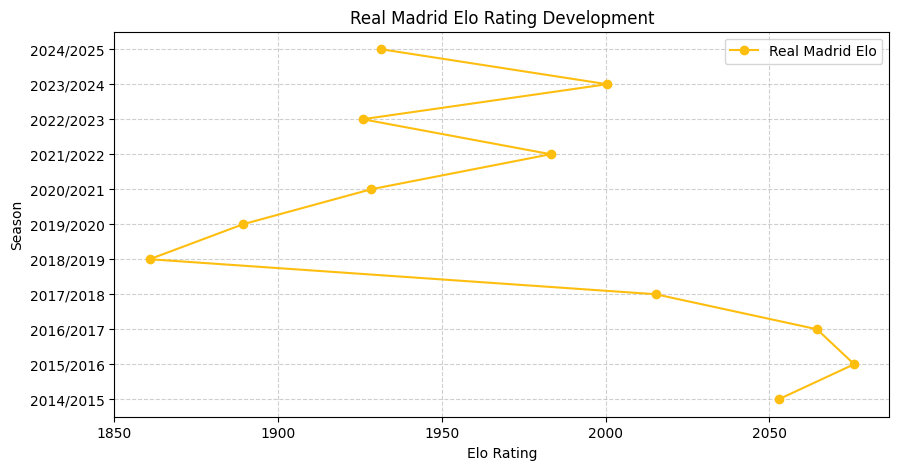

In [61]:
plt.figure(figsize=(10, 5))

plt.plot(real_madrid_elo_ratings, seasons, marker='o', linestyle='-', color='#FEBE10', label='Real Madrid Elo')

plt.title('Real Madrid Elo Rating Development')
plt.xlabel('Elo Rating')
plt.ylabel('Season')
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()
plt.show()

Well now lets compare this with the team of Barcelona in the same situation:

In [62]:
barcelona_elo_ratings = elo_ratings_interim[elo_ratings_interim['team_name'] == 'Barcelona']['team_elo_rating'].values

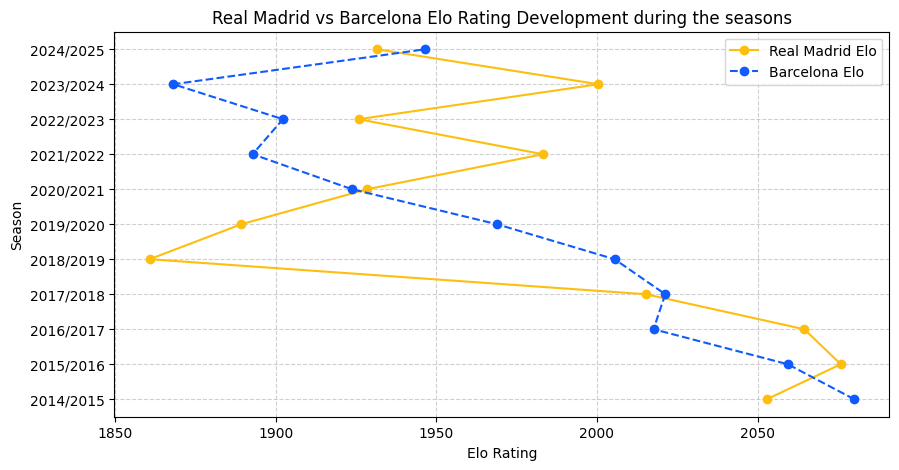

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(real_madrid_elo_ratings, seasons, marker='o', linestyle='-', color='#FEBE10', label='Real Madrid Elo')
plt.plot(barcelona_elo_ratings, seasons, marker='o', linestyle='--', color="#105BFE", label='Barcelona Elo')


plt.title('Real Madrid vs Barcelona Elo Rating Development during the seasons')
plt.xlabel('Elo Rating')
plt.ylabel('Season')
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()
plt.show()

Well one thing which could be seen for sure, is that both of teams are getting worse and worse during the years, with little deviations of course, but if we look at the main picture, for sure there is a huge down in their performances as the seasons increses!

## Saving the interim version of the dataset:
Ok, now lastly lets save the interim version of the dataset into the interim directory!

But before that I should craete the specific elo_ratings directory, where the elo ratings datasets intermediate versions will be stored:

In [64]:
# force working directory to project root
PROJECT_ROOT = Path().resolve().parent.parent

In [65]:
PROJECT_ROOT

WindowsPath('C:/Users/Asus/Desktop/Data_Science/Football_Betting_Analysis/Football_Betting_Analysis')

In [66]:
# The ELO_RATINGS_INTERIM_PATH is a constant defined in the scr/config.py script which is used to store global variables and important constants among the project!
file_path = PROJECT_ROOT / ELO_RATINGS_INTERIM_PATH
file_path.mkdir(parents=True, exist_ok=True)

And now lets save the data into the elo ratings interim dir we have just created.

I will save the data using the `save_data` functions.For the function implementation visit this link: [save_data](../../src/football_betting_analysis/data/save_data_into_file.py) 

In [67]:
interim_elo_ratings_path = PROJECT_ROOT / ELO_RATINGS_INTERIM_PATH / 'interim_elo_ratings_v1.parquet'

save_data(data=elo_ratings_interim, file_path=interim_elo_ratings_path)

The file has already been created and it contains the exact data as the original dataset!


---

## Matches: 
Now lets proceed with the next dataset, which is the Matches dataset!

**What is the **Matches** dataset about?** \
The matches dataset is much likely the previous one, that we have been dealing with, but this one contains elo ratings for match-level data.More simply, the dataset provides match-level data, including match stats, goals, shots, match conetext details and most importantly it provides elo ratings data for each of the teams in the matches.

**To what refers the elo ratings for the matches?** \
Well, the elo ratings in the dataset are the calculated most recent teams elo ratings before the specific match.This means that for each of the matches the elo ratings data represent the latest, more recent elo rating of the specific team.That's, actually, the reason why I have removed all of the teams elo ratings for the different dates and left only their final, most accurate ratings for each of the seasons - just because the current **Matches** dataset provides the exact same data and even more professional and useful because it is at **match-level.**

Ok now lets explain each of the features of the dataset, so that we can get a better understanding of what we are dealing with:

## Data understanding

#### Dataset features:

**Division** -> League that the match was played in - country code + division number (I1 for Italian First Division). \
**MatchDate** -> Match date in the classic YYYY-MM-DD format. \
**MatchTime** -> Match time in the HH:MM:SS format. CET-1 timezone. \
**HomeTeam** -> Home team's club name in English, abbreviated if needed. \
**AwayTeam** -> Home team's club name in English, abbreviated if needed. \
**HomeElo** -> Home team's most recent Elo rating. \
**AwayElo**	-> Away team's most recent Elo rating. \
**Form3Home** -> Number of points gathered by home team in the last 3 matches (Win = 3 points, Draw = 1 point, Loss = 0 points, so this value is between 0 and 9). \
**Form5Home** -> Number of points gathered by home team in the last 5 matches (Win = 3 points, Draw = 1 point, Loss = 0 points, so this value is between 0 and 15). \
**Form3Away** -> Number of points gathered by away team in the last 3 matches (Win = 3 points, Draw = 1 point, Loss = 0 points, so this value is between 0 and 9). \
**Form5Away** -> Number of points gathered by away team in the last 5 matches (Win = 3 points, Draw = 1 point, Loss = 0 points, so this value is between 0 and 15). \
**FTHome** -> Full-time goals scored by home team. \
**FTAway** -> Full-time goals scored by away team. \
**FTResult** -> Full-time result (H for Home win, D for Draw and A for Away win). \
**HTHome** -> Half-time goals scored by home team. \
**HTAway** -> Half-time goals scored by away team. \
**HTResult** -> Half-time result (H for Home win, D for Draw and A for Away win). \
**HomeShots** -> Total shots (goal, saved, blocked, off-target) by home team. \
**AwayShots** -> Total shots (goal, saved, blocked, off-target) by away team. \
**HomeTarget** -> Total shots on target (goal, saved) by home team. \
**AwayTarget** -> Total shots on target (goal, saved) by away team. \
**HomeFouls** -> Total fouls by home team. \
**AwayFouls** -> Total fouls by away team. \
**HomeCorners**	-> Total corners taken by home team. \
**AwayCorners**	-> Total corners taken by away team. \
**HomeYellow**	-> Total yellow cards awarded to home team players (excl. staff). \
**AwayYellow** -> Total yellow cards awarded to away team players (excl. staff). \
**HomeRed**	-> Total red cards awarded to home team players (excl. staff). \
**AwayRed** -> Total red cards awarded to away team players (excl. staff). \
**OddHome**	-> Bet365's Home Team Win Odd. \
**OddDraw**	-> Bet365's Draw Odd. \
**OddAway**	-> Bet365's Away Team Win Odd. \
**MaxHome**	-> Maximum Home Team Win Odd from around 17 European bookmakers. \
**MaxDraw**	-> Maximum Draw Odd from around 17 European bookmakers. \
**MaxAway**	-> Maximum Away Team Win Odd from around 17 European bookmakers. \
**Over25**	-> Bet365's Over 2.5 Total Goals Scored Odd. \
**Under25**	-> Bet365's Under 2.5 Total Goals Scored Odd. \
**MaxOver25** -> Maximum Over 2.5 Total Goals Scored Odd from around 17 European bookmakers. \
**MaxUnder25** -> Maximum Under 2.5 Total Goals Scored Odd from around 17 European bookmakers. \
**HandiSize** -> Asian handicap size for home team (negative number indicating stronger home team) . \
**HandiHome** -> Bet365's Home Team Win Odd with the given handicap size for Home team. \
**HandiAway** -> Bet365's Away Team Win Odd with the given handicap size for Home team. \
**C_LTH** -> Likeliness of match falling into the Low Tempo Home-oriented match cluster. \
**C_LTA** -> Likeliness of match falling into the Low Tempo Away-oriented match cluster. \
**C_VHD** -> Likeliness of match falling into the Visibly Home Dominated match cluster. \
**C_VAD** -> Likeliness of match falling into the Visibly Away Dominated match cluster. \
**C_HTB** -> Likeliness of match falling into the High Tempo Balanced match cluster. \
**C_PHB** -> Likeliness of match falling into the Highly Physical Balanced match cluster. \

This is what the dataset contains as features!We can see that there are many of them!And what I can see that many of them are useless and I already have them from other datasets!But before saying strong words, lets explore the dataset and see what should be cleaned!

So lets start by loading the dataset:

In [68]:
matches = pd.read_csv('../../data/raw/elo_ratings/Matches.csv')

C:\Users\Asus\AppData\Local\Temp\ipykernel_7604\3654091980.py:1: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  matches = pd.read_csv('../../data/raw/elo_ratings/Matches.csv')


## Data exploration

From now we can see that there are mixed date time format, but this only for the MatchTime column, not for the MatchDate(which is important for us), so this will not be a very big problem.

However, lets see the dataset:

In [69]:
matches

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230552,SP2,2025-06-01,17:30:00,Cartagena,Mirandes,1339.21,1544.15,3.0,6.0,7.0,...,2.40,1.8,1.95,1.85,0.0209,0.0118,0.0099,0.8084,0.1386,0.0104
230553,SP2,2025-06-01,17:30:00,Almeria,Tenerife,1544.16,1433.67,4.0,10.0,1.0,...,2.55,-1.8,1.80,2.00,0.3799,0.0630,0.2806,0.0160,0.2332,0.0274
230554,SP2,2025-06-01,17:30:00,La Coruna,Elche,1473.67,1569.98,0.0,3.0,3.0,...,2.63,1.3,1.78,2.03,0.0224,0.7482,0.0100,0.1201,0.0180,0.0813
230555,SP2,2025-06-01,17:30:00,Oviedo,Cadiz,1574.90,1525.76,7.0,13.0,6.0,...,1.51,-0.8,1.95,1.85,0.2070,0.2490,0.2334,0.0211,0.2634,0.0261


In [70]:
matches.shape

(230557, 48)

In [71]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  str    
 1   MatchDate    230557 non-null  str    
 2   MatchTime    99072 non-null   str    
 3   HomeTeam     230557 non-null  str    
 4   AwayTeam     230557 non-null  str    
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  str    
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  str    
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-null  float

Ok, this dataset is really really messy.It contains too much useless and missing features.What I can say, is that it has a lot of things to cleaned here and more importantly reduced!

And that is the first thing that I will do.I will reduce the size of the dataset, by getting only the matches from the Spanish La Liga(the first division) and the ones which are from the seasons **2014/2015 to 2024/2025**!

But before doing that I need to do one other thing first, and this is to fix the MatchDate column type to datetime, because it will be easier for me to work with a datetime object, rather than using a raw string dates.It is just going to be very, very helpful to me, so lets do it!

In [72]:
matches_interim = matches.copy()

## Coverting the MatchDate column type to a datetime obeject: 

The function which I will use for this jon is the `convert_string_to_datetime` func, which is implemented at this link: [convert_string_to_datetime](../../src/football_betting_analysis/data/data_cleaning.py).

The function will automatically throw an error if there is incosistency among the datetime formats in the column!

In [73]:
matches_interim['MatchDate'] = convert_string_to_datetime(matches_interim['MatchDate'], '%Y-%m-%d')

In [74]:
matches_interim['MatchDate']

0        2000-07-28
1        2000-07-28
2        2000-07-28
3        2000-07-29
4        2000-07-29
            ...    
230552   2025-06-01
230553   2025-06-01
230554   2025-06-01
230555   2025-06-01
230556   2025-06-01
Name: MatchDate, Length: 230557, dtype: datetime64[us]

Ok now we are good to go!

## Reducing the size of the dataset, by getting only the matches from Spanish first division from seasons 2014/2015 to 2024/2025:

Lets reduce the dataset.For the the Spanish first division, I will use the constant: `LEAGUE_CODE_FD`(SP1).For the seasons I will only get the matches data from **1 of august(when a typical season starts) 2014 to 31 of may(when a typical season ends) 2025** of the Spanish La Liga!

> A typical football season starts in starts in August (month 8) and ends in May (month 5).

In the end we should end up with a total of 4180 matches, 380 matches per season and 38 matches per team for each of the seasons:

In [75]:
matches_interim = matches_interim[
    (matches_interim['MatchDate'] >= '2014-08-01') &
    (matches_interim['MatchDate'] <= '2025-05-31') &
    (matches_interim['Division'] == LEAGUE_CODE_FD)
]

In [76]:
matches_interim

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
102379,SP1,2014-08-23,NaN,Almeria,Espanol,1688.44,1701.25,7.0,10.0,1.0,...,1.70,0.0,1.91,1.94,0.1369,0.0425,0.0146,0.0100,0.0123,0.7838
102380,SP1,2014-08-23,NaN,Granada,La Coruna,1672.54,1647.85,4.0,4.0,3.0,...,1.61,-0.5,2.04,1.84,0.0729,0.4008,0.0103,0.2977,0.1826,0.0357
102381,SP1,2014-08-23,NaN,Malaga,Ath Bilbao,1754.00,1841.42,4.0,7.0,5.0,...,1.85,0.0,2.03,1.83,0.6630,0.0323,0.0227,0.0171,0.0389,0.2259
102382,SP1,2014-08-23,NaN,Sevilla,Valencia,1845.38,1803.59,4.0,7.0,4.0,...,2.00,-0.5,2.03,1.84,0.1626,0.0202,0.7699,0.0099,0.0138,0.0235
102525,SP1,2014-08-24,NaN,Barcelona,Elche,2024.84,1682.16,3.0,9.0,4.0,...,3.85,-2.5,1.77,2.10,0.0716,0.0285,0.0712,0.0162,0.5091,0.3034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230497,SP1,2025-05-24,20:00:00,Getafe,Celta,1634.54,1694.08,3.0,3.0,6.0,...,1.83,0.5,2.00,1.85,0.0528,0.3012,0.0100,0.5250,0.0678,0.0432
230498,SP1,2025-05-24,20:00:00,Vallecano,Mallorca,1651.11,1652.13,7.0,10.0,3.0,...,1.78,-1.0,1.95,1.90,0.0274,0.0314,0.1297,0.0114,0.7766,0.0235
230499,SP1,2025-05-25,13:00:00,Girona,Ath Madrid,1655.05,1856.09,3.0,7.0,6.0,...,2.40,0.5,1.93,1.93,0.0314,0.0167,0.0099,0.9125,0.0154,0.0141
230500,SP1,2025-05-25,15:15:00,Villarreal,Sevilla,1769.85,1648.82,9.0,15.0,3.0,...,2.65,-1.3,2.00,1.85,0.3187,0.0283,0.1637,0.0285,0.4188,0.0421


Well, at this moment everything seems to be perfect, because the matches are just as we have expected: 4180!

Now lets check the other two things that we also expect to be right: 380 matches per season and 38 matches per team in each season!

But in order to do that, I am required to add a new feature to the dataset, which will be the match **season**.This features is really important because it helps to identidy when a match was played and more importantly serves as feature which will be used in matches categorization, groups and unique part of a duplicate criteria check!

## Adding additional features to the dataset:

To do so, I will just check if the date month of the match is higher than 8(august), if so I will return the season in format `YYYY/YYYY+1`, if not I will return the season in format `YYYY/YYYY-1`

Lets do it:

In [77]:
matches_interim['season'] = np.where(
    matches_interim['MatchDate'].dt.month >= 8,
    matches_interim['MatchDate'].dt.year.astype(str) + '/' + (matches_interim['MatchDate'].dt.year + 1).astype(str),
    (matches_interim['MatchDate'].dt.year - 1).astype(str) + '/' + matches_interim['MatchDate'].dt.year.astype(str)
)

We can see that the above code is only possible, because we have casted the MatchDate column to a datetime object.That's why I do it!

In [78]:
matches_interim

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,season
102379,SP1,2014-08-23,NaN,Almeria,Espanol,1688.44,1701.25,7.0,10.0,1.0,...,0.0,1.91,1.94,0.1369,0.0425,0.0146,0.0100,0.0123,0.7838,2014/2015
102380,SP1,2014-08-23,NaN,Granada,La Coruna,1672.54,1647.85,4.0,4.0,3.0,...,-0.5,2.04,1.84,0.0729,0.4008,0.0103,0.2977,0.1826,0.0357,2014/2015
102381,SP1,2014-08-23,NaN,Malaga,Ath Bilbao,1754.00,1841.42,4.0,7.0,5.0,...,0.0,2.03,1.83,0.6630,0.0323,0.0227,0.0171,0.0389,0.2259,2014/2015
102382,SP1,2014-08-23,NaN,Sevilla,Valencia,1845.38,1803.59,4.0,7.0,4.0,...,-0.5,2.03,1.84,0.1626,0.0202,0.7699,0.0099,0.0138,0.0235,2014/2015
102525,SP1,2014-08-24,NaN,Barcelona,Elche,2024.84,1682.16,3.0,9.0,4.0,...,-2.5,1.77,2.10,0.0716,0.0285,0.0712,0.0162,0.5091,0.3034,2014/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230497,SP1,2025-05-24,20:00:00,Getafe,Celta,1634.54,1694.08,3.0,3.0,6.0,...,0.5,2.00,1.85,0.0528,0.3012,0.0100,0.5250,0.0678,0.0432,2024/2025
230498,SP1,2025-05-24,20:00:00,Vallecano,Mallorca,1651.11,1652.13,7.0,10.0,3.0,...,-1.0,1.95,1.90,0.0274,0.0314,0.1297,0.0114,0.7766,0.0235,2024/2025
230499,SP1,2025-05-25,13:00:00,Girona,Ath Madrid,1655.05,1856.09,3.0,7.0,6.0,...,0.5,1.93,1.93,0.0314,0.0167,0.0099,0.9125,0.0154,0.0141,2024/2025
230500,SP1,2025-05-25,15:15:00,Villarreal,Sevilla,1769.85,1648.82,9.0,15.0,3.0,...,-1.3,2.00,1.85,0.3187,0.0283,0.1637,0.0285,0.4188,0.0421,2024/2025


## Validating matches, seasons, teams occurances in the dataset: 

Ok, now it is the time to check if the check if: **380 matches per season and 38 matches per team in each season!**

In [79]:
seasons = [f"{str(year)}/{str(year+1)}" for year in range(START_SEASON, END_SEASON)]

In [80]:
for season in seasons:
    current_season_matches = matches_interim[matches_interim['season'] == season]
    print(f'Season: {season}, Matches: {len(current_season_matches)}')

Season: 2014/2015, Matches: 380
Season: 2015/2016, Matches: 380
Season: 2016/2017, Matches: 380
Season: 2017/2018, Matches: 380
Season: 2018/2019, Matches: 380
Season: 2019/2020, Matches: 380
Season: 2020/2021, Matches: 380
Season: 2021/2022, Matches: 380
Season: 2022/2023, Matches: 380
Season: 2023/2024, Matches: 380
Season: 2024/2025, Matches: 380


Ok this is perfect, but now lets check if there a total of 38 matches for each of teams in each of the seasons.

This is something which I have used to check in the other datasets to, so what I have done, is that I have moved this validation into a dedicated script `team_match_validation` which contains the function `validate_team_matches` which simply validates if every team in each of the seasons from **2014/2015 to 2024/2025** has played a total of 38 matches - The excat thing that we want to check now!

For the function implemenation visit this link: [validate_team_matches](../../src/football_betting_analysis/data/team_match_validation.py)

Now lets test it:

In [81]:
valid_teams = validate_team_matches(matches_interim, 'HomeTeam', 'AwayTeam')

In [82]:
valid_teams

{'2014/2015': 20,
 '2015/2016': 20,
 '2016/2017': 20,
 '2017/2018': 20,
 '2018/2019': 20,
 '2019/2020': 20,
 '2020/2021': 20,
 '2021/2022': 20,
 '2022/2023': 20,
 '2023/2024': 20,
 '2024/2025': 20}

Everything is just perfect!

Now lets proceed with something very very important:
## Mapping different datasets names:

What I want to now is that I want to check if the teams names in the the current dataset(**Matches**) are the same as the ones from the Understat matches data.If there are any inconsistencies between the names of the different datasets, I must fix them and make them consistent and ready for future analyses and more imporantly merges!

**Why I use the Understat data?** \
Because the Understat data provides the names of the teams in there full variant without any abbriviations or inconsistencies!That's why!

We already have got the team names of the Understat data:

In [83]:
understat_all_teams

{'2014/2015': <ArrowStringArray>
 [             'Malaga',             'Sevilla',             'Granada',
              'Almeria',               'Eibar',           'Barcelona',
           'Celta Vigo',             'Levante',         'Real Madrid',
       'Rayo Vallecano',              'Getafe',            'Valencia',
              'Cordoba',       'Athletic Club',     'Atletico Madrid',
             'Espanyol',          'Villarreal', 'Deportivo La Coruna',
        'Real Sociedad',               'Elche']
 Length: 20, dtype: str,
 '2015/2016': <ArrowStringArray>
 [             'Malaga', 'Deportivo La Coruna',            'Espanyol',
      'Atletico Madrid',      'Rayo Vallecano',       'Athletic Club',
       'Sporting Gijon',             'Levante',          'Real Betis',
              'Granada',          'Villarreal',       'Real Sociedad',
            'Barcelona',          'Celta Vigo',         'Real Madrid',
                'Eibar',             'Sevilla',            'Valencia',
         

Now lets first check what names do we have in out dataset(**Matches**):

In [84]:
elo_matches_all_teams = (
    matches_interim
        .groupby('season')['HomeTeam']
            .unique()
            .to_dict()
)

In [85]:
elo_matches_all_teams

{'2014/2015': <ArrowStringArray>
 [    'Almeria',     'Granada',      'Malaga',     'Sevilla',   'Barcelona',
        'Celta',       'Eibar',     'Levante', 'Real Madrid',   'Vallecano',
       'Getafe',    'Valencia',  'Ath Bilbao',  'Ath Madrid',     'Cordoba',
      'Espanol',       'Elche',   'La Coruna',    'Sociedad',  'Villarreal']
 Length: 20, dtype: str,
 '2015/2016': <ArrowStringArray>
 [     'Malaga',  'Ath Madrid',     'Espanol',   'La Coruna',   'Vallecano',
   'Ath Bilbao',       'Betis',     'Levante',    'Sp Gijon',     'Granada',
   'Villarreal',   'Barcelona',       'Celta', 'Real Madrid',    'Sociedad',
        'Eibar',      'Getafe',  'Las Palmas',     'Sevilla',    'Valencia']
 Length: 20, dtype: str,
 '2016/2017': <ArrowStringArray>
 [  'La Coruna',      'Malaga',   'Barcelona',     'Granada',     'Sevilla',
   'Ath Madrid',    'Sociedad',    'Sp Gijon',       'Celta',    'Valencia',
        'Betis',     'Espanol',       'Eibar',     'Leganes',     'Osasuna',
  'R

Well, even from now I can see that there are clear differences.But lets ensure that!

Just for the example I will get the teams names from season 2014/2015, order the names aphabetically and compare them: 

In [86]:
sorted(understat_all_teams['2014/2015']) == sorted(elo_matches_all_teams['2014/2015'])

False

We can clearly see that there are differences!

So what we should do is that we should remove these differences, by mapping the names from the elo matches dataset to be the same as the ones from the Understat data.

As I have done it for the previous dataset that we have cleaned(The **EloRatings** dataset), I will use a mapping algprithm, already implemented earlier, which simply first normalizes the names of the both sources and then uses a mapper which maps the wrong data names to the ones we want to get!

The whole algorithm process was detaily described in the cleaning section of the previous dataset!So what I will do now is that I will use the function `build_team_mapping` which is defined in the following script: [teams_names_mapper](../../src/football_betting_analysis/data/teams_names_mapper.py)

So lets apply the mapping fucntion to the **elo matches** dataset!

I will do that on other df which will be a copy of the original.That's just to be sure that we are not going to break anyting in the original.So:

In [87]:
matches_df = matches_interim.copy()

Now lets create the spcific aliases which we will use for the mapping.They are the same as the ones form the EloRatings maping process, but just be visual clear what we are using!

In [88]:
elo_matches_aliases = {
    "ath bilbao": "Athletic Club",
    "ath madrid": "Atletico Madrid",
    "sp gijon": "Sporting Gijon"
}

Now lets apply the mapping function which will give us the dicts with the teams names mappings:

In [89]:
seasons = [f"{str(year)}/{str(year+1)}" for year in range(START_SEASON, END_SEASON)]
    
season_mappings = {}
season_unresolved = {}

for season in seasons:
    source_names = elo_matches_all_teams[season]
    target_names = understat_all_teams[season]

    mapping, unresolved = build_team_mapping(
        normalize=normalize,
        source_names=source_names,
        target_names=target_names,
        aliases=elo_matches_aliases
    )

    season_mappings[season] = mapping
    season_unresolved[season] = unresolved

Now the function which will use the mapping dicts that we have created from above and map the names row by row into the Elo Matches dataset.

The function accepts a `team_type_column` which is the column of the team name in the match: either the HomeTeam or the AwayTeam.The function should apply the mapping for the both dataset columns!

In [90]:
def map_team(row, team_type_column: str):
    season = row['season']
    team = row[team_type_column]

    mapping = season_mappings.get(season, {})

    return mapping.get(team, None)

Now lets finally apply the mapping into the dataset, using the function above.

First I will apply the function for the Home teams and then for the Away ones:

In [91]:
matches_df['HomeTeam_clean'] = matches_df.apply(lambda row: map_team(row, 'HomeTeam'), axis=1)

And now lets do the same for the AwayTeam column:

In [92]:
matches_df['AwayTeam_clean'] = matches_df.apply(lambda row: map_team(row, 'AwayTeam'), axis=1)

In [93]:
matches_df

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,season,HomeTeam_clean,AwayTeam_clean
102379,SP1,2014-08-23,NaN,Almeria,Espanol,1688.44,1701.25,7.0,10.0,1.0,...,1.94,0.1369,0.0425,0.0146,0.0100,0.0123,0.7838,2014/2015,Almeria,Espanyol
102380,SP1,2014-08-23,NaN,Granada,La Coruna,1672.54,1647.85,4.0,4.0,3.0,...,1.84,0.0729,0.4008,0.0103,0.2977,0.1826,0.0357,2014/2015,Granada,Deportivo La Coruna
102381,SP1,2014-08-23,NaN,Malaga,Ath Bilbao,1754.00,1841.42,4.0,7.0,5.0,...,1.83,0.6630,0.0323,0.0227,0.0171,0.0389,0.2259,2014/2015,Malaga,Athletic Club
102382,SP1,2014-08-23,NaN,Sevilla,Valencia,1845.38,1803.59,4.0,7.0,4.0,...,1.84,0.1626,0.0202,0.7699,0.0099,0.0138,0.0235,2014/2015,Sevilla,Valencia
102525,SP1,2014-08-24,NaN,Barcelona,Elche,2024.84,1682.16,3.0,9.0,4.0,...,2.10,0.0716,0.0285,0.0712,0.0162,0.5091,0.3034,2014/2015,Barcelona,Elche
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230497,SP1,2025-05-24,20:00:00,Getafe,Celta,1634.54,1694.08,3.0,3.0,6.0,...,1.85,0.0528,0.3012,0.0100,0.5250,0.0678,0.0432,2024/2025,Getafe,Celta Vigo
230498,SP1,2025-05-24,20:00:00,Vallecano,Mallorca,1651.11,1652.13,7.0,10.0,3.0,...,1.90,0.0274,0.0314,0.1297,0.0114,0.7766,0.0235,2024/2025,Rayo Vallecano,Mallorca
230499,SP1,2025-05-25,13:00:00,Girona,Ath Madrid,1655.05,1856.09,3.0,7.0,6.0,...,1.93,0.0314,0.0167,0.0099,0.9125,0.0154,0.0141,2024/2025,Girona,Atletico Madrid
230500,SP1,2025-05-25,15:15:00,Villarreal,Sevilla,1769.85,1648.82,9.0,15.0,3.0,...,1.85,0.3187,0.0283,0.1637,0.0285,0.4188,0.0421,2024/2025,Villarreal,Sevilla


Now lets ensure that there are not any missing values:

In [94]:
len(matches_df[
    (matches_df['HomeTeam_clean'].notna()) &
    (matches_df['AwayTeam_clean'].notna())
]) == len(matches_df)


True

Ok this is ok:

Now lets put the clean teams names into the original columns and remove the helping columns:

In [95]:
matches_df['HomeTeam'] = matches_df['HomeTeam_clean']
matches_df['AwayTeam'] = matches_df['AwayTeam_clean']

matches_df = matches_df.drop(columns='HomeTeam_clean')
matches_df = matches_df.drop(columns='AwayTeam_clean')

In [96]:
matches_df

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,season
102379,SP1,2014-08-23,NaN,Almeria,Espanyol,1688.44,1701.25,7.0,10.0,1.0,...,0.0,1.91,1.94,0.1369,0.0425,0.0146,0.0100,0.0123,0.7838,2014/2015
102380,SP1,2014-08-23,NaN,Granada,Deportivo La Coruna,1672.54,1647.85,4.0,4.0,3.0,...,-0.5,2.04,1.84,0.0729,0.4008,0.0103,0.2977,0.1826,0.0357,2014/2015
102381,SP1,2014-08-23,NaN,Malaga,Athletic Club,1754.00,1841.42,4.0,7.0,5.0,...,0.0,2.03,1.83,0.6630,0.0323,0.0227,0.0171,0.0389,0.2259,2014/2015
102382,SP1,2014-08-23,NaN,Sevilla,Valencia,1845.38,1803.59,4.0,7.0,4.0,...,-0.5,2.03,1.84,0.1626,0.0202,0.7699,0.0099,0.0138,0.0235,2014/2015
102525,SP1,2014-08-24,NaN,Barcelona,Elche,2024.84,1682.16,3.0,9.0,4.0,...,-2.5,1.77,2.10,0.0716,0.0285,0.0712,0.0162,0.5091,0.3034,2014/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230497,SP1,2025-05-24,20:00:00,Getafe,Celta Vigo,1634.54,1694.08,3.0,3.0,6.0,...,0.5,2.00,1.85,0.0528,0.3012,0.0100,0.5250,0.0678,0.0432,2024/2025
230498,SP1,2025-05-24,20:00:00,Rayo Vallecano,Mallorca,1651.11,1652.13,7.0,10.0,3.0,...,-1.0,1.95,1.90,0.0274,0.0314,0.1297,0.0114,0.7766,0.0235,2024/2025
230499,SP1,2025-05-25,13:00:00,Girona,Atletico Madrid,1655.05,1856.09,3.0,7.0,6.0,...,0.5,1.93,1.93,0.0314,0.0167,0.0099,0.9125,0.0154,0.0141,2024/2025
230500,SP1,2025-05-25,15:15:00,Villarreal,Sevilla,1769.85,1648.82,9.0,15.0,3.0,...,-1.3,2.00,1.85,0.3187,0.0283,0.1637,0.0285,0.4188,0.0421,2024/2025


Now lets ensure that everything is perfect:

In [97]:
matches_df.groupby('season')['HomeTeam'].nunique()

season
2014/2015    20
2015/2016    20
2016/2017    20
2017/2018    20
2018/2019    20
2019/2020    20
2020/2021    20
2021/2022    20
2022/2023    20
2023/2024    20
2024/2025    20
Name: HomeTeam, dtype: int64

In [98]:
matches_df.groupby('season')['AwayTeam'].nunique()

season
2014/2015    20
2015/2016    20
2016/2017    20
2017/2018    20
2018/2019    20
2019/2020    20
2020/2021    20
2021/2022    20
2022/2023    20
2023/2024    20
2024/2025    20
Name: AwayTeam, dtype: int64

And now the most important validation.Are the teams names in the two datasets perfectly consistent for each of the seasons: 

In [99]:
valid_seasons = 0
for season in seasons:
    current_elo_matching_teams_names = sorted(matches_df[matches_df['season'] == season]['HomeTeam'].unique())
    current_understat_teams_names = sorted(understat_matches[understat_matches['season'] == season]['h_title'].unique())
    
    if current_elo_matching_teams_names == current_understat_teams_names:
        valid_seasons += 1

valid_seasons

11

#### Well we have 11 perfectly valid seasons each with valid and consistent teams names!

As we have cleaned the dataset and ensured that it is with valid and consistent teams names, not lest return back the original name of the dataset:

In [100]:
matches_interim = matches_df

In [101]:
matches_interim

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,season
102379,SP1,2014-08-23,NaN,Almeria,Espanyol,1688.44,1701.25,7.0,10.0,1.0,...,0.0,1.91,1.94,0.1369,0.0425,0.0146,0.0100,0.0123,0.7838,2014/2015
102380,SP1,2014-08-23,NaN,Granada,Deportivo La Coruna,1672.54,1647.85,4.0,4.0,3.0,...,-0.5,2.04,1.84,0.0729,0.4008,0.0103,0.2977,0.1826,0.0357,2014/2015
102381,SP1,2014-08-23,NaN,Malaga,Athletic Club,1754.00,1841.42,4.0,7.0,5.0,...,0.0,2.03,1.83,0.6630,0.0323,0.0227,0.0171,0.0389,0.2259,2014/2015
102382,SP1,2014-08-23,NaN,Sevilla,Valencia,1845.38,1803.59,4.0,7.0,4.0,...,-0.5,2.03,1.84,0.1626,0.0202,0.7699,0.0099,0.0138,0.0235,2014/2015
102525,SP1,2014-08-24,NaN,Barcelona,Elche,2024.84,1682.16,3.0,9.0,4.0,...,-2.5,1.77,2.10,0.0716,0.0285,0.0712,0.0162,0.5091,0.3034,2014/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230497,SP1,2025-05-24,20:00:00,Getafe,Celta Vigo,1634.54,1694.08,3.0,3.0,6.0,...,0.5,2.00,1.85,0.0528,0.3012,0.0100,0.5250,0.0678,0.0432,2024/2025
230498,SP1,2025-05-24,20:00:00,Rayo Vallecano,Mallorca,1651.11,1652.13,7.0,10.0,3.0,...,-1.0,1.95,1.90,0.0274,0.0314,0.1297,0.0114,0.7766,0.0235,2024/2025
230499,SP1,2025-05-25,13:00:00,Girona,Atletico Madrid,1655.05,1856.09,3.0,7.0,6.0,...,0.5,1.93,1.93,0.0314,0.0167,0.0099,0.9125,0.0154,0.0141,2024/2025
230500,SP1,2025-05-25,15:15:00,Villarreal,Sevilla,1769.85,1648.82,9.0,15.0,3.0,...,-1.3,2.00,1.85,0.3187,0.0283,0.1637,0.0285,0.4188,0.0421,2024/2025


Now we can proceed with the more standard procedures:

## Checking for missing values and removing features from the dataset:

Now lets see are there any missing values in the dataset, and if there are, how should we deal with them?

In [102]:
matches_interim.info()

<class 'pandas.DataFrame'>
Index: 4180 entries, 102379 to 230535
Data columns (total 49 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Division     4180 non-null   str           
 1   MatchDate    4180 non-null   datetime64[us]
 2   MatchTime    2280 non-null   str           
 3   HomeTeam     4180 non-null   str           
 4   AwayTeam     4180 non-null   str           
 5   HomeElo      4180 non-null   float64       
 6   AwayElo      4180 non-null   float64       
 7   Form3Home    4180 non-null   float64       
 8   Form5Home    4180 non-null   float64       
 9   Form3Away    4180 non-null   float64       
 10  Form5Away    4180 non-null   float64       
 11  FTHome       4180 non-null   float64       
 12  FTAway       4180 non-null   float64       
 13  FTResult     4180 non-null   str           
 14  HTHome       4180 non-null   float64       
 15  HTAway       4180 non-null   float64       
 16  HTResult     41

Well from what I can see the only column which contain missing values is the **MatchTime**, but lets ensure that:

In [103]:
df_columns = matches_interim.isna().any()

columns_with_missing_values = df_columns[df_columns.values == True]
columns_with_missing_values

MatchTime    True
HandiHome    True
HandiAway    True
dtype: bool

Ok, there are three columns which contain missing values and we can see them from above!

One column which I can freely remove from now is the **MatchTime** column, which is just useless to the dataset when we alredy have a **MatchDate** column.The **MatchTime** would have been useful if I needed the exact time when the matches have started, but this is no of interest to me.It is neither of the columns which I consider **meaningful** - In the [01_football_data_co_uk_cleaning](../cleaning/01_football_data_co_uk_cleaning.ipynb) notebook I have clearly described what a meaningful column is, so you can check it!

Now lets remove this column:

In [104]:
matches_interim = matches_interim.drop(columns=['MatchTime'])

This is done. Now what about the others?

In [105]:
df_columns = matches_interim.isna().any()

columns_with_missing_values = df_columns[df_columns.values == True]
columns_with_missing_values

HandiHome    True
HandiAway    True
dtype: bool

Well, in order to decide if these two columns would be useful to the dataset and for the objectives of the project, lets first understand what they are about:

The columns root is a special betting definition which is: **Hendicap**!

What is a **Hendicap**? \
A **handicap** in football (soccer) betting refers to a, **virtual, goal advantage or deficit** assigned to teams by bookmakers before a match begins to level the playing field, making **one-sided games more competitive for wagering**.For example a -1.5 handicap means the favorite must win by 2+ goals, while a +1.5 handicap means the underdog can lose by 1, draw, or win, and the bet still wins.

How the **Hendicap** is used betting? \
The hendicap, as the normal betting odds, could be betted on it and if you successed in predicting the match outcome you will win.Yes, but there is one difference: In the hendicap betting you do not bet on clear match outcomes(like win, draw, lose), you bet on a **goal margin** or a **margin of victory**.For example if you want to bet on a specific team and its hendicap is -2.5, this means that in order for you to win, the team you have betted on, should win the match with more than 2 goals.If the team win the match but only wiht 1 or 2 goals, you will not win.And also there is the fact that if the other tema scores a goal, the victory margin of your team will fall to 1.5 goals etc.So yes there is a big difference from the normal betting odds!

Ok, but could these handicap metrics be useful for something in our project? \
A given handicap metric is considered **highly helpful** in football match predictions because it often reflects superior insights into **likely margins of victory** compared to simple 1X2 (win-draw-loss) models, with some studies showing prediction accuracy above **70%** when utilizing handicap data.I cannot fully state that this metric will increase the models predictions, but why not?

**Reflects Expected Margin:** Unlike simple win/draw/lose bets, handicap lines show the expected margin of victory, not just who wins.

**Higher Accuracy/Efficiency:** Because handicap markets often have lower margins for bookmakers (especially Asian Handicaps), they are used heavily by professional bettors, meaning the lines often reflect a more accurate consensus of the true probability of a team's performance.

**Closing Line Value (CLV):** Consistently beating the handicap line (taking a better price before the market moves) is considered the best indicator of long-term betting success
Given the fact that this mre

Having the information above, why would we miss the chance, these metrics to improve the models predictions!I think that it is logical that we leave them!But the question what should we do with the ones that are missing.

Lets see for which matches are they missing:

In [106]:
matches_with_missing_values = matches_interim[
    (matches_interim['HandiHome'].isna()) |
    (matches_interim['HandiAway'].isna())
]

matches_with_missing_values

,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,...,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,season
172527,SP1,2020-07-19,Alaves,Barcelona,1639.66,1976.68,4.0,4.0,6.0,10.0,...,1.0,NaN,NaN,0.3219,0.2085,0.0192,0.1124,0.1720,0.1661,2019/2020
172544,SP1,2020-07-19,Real Valladolid,Real Betis,1653.82,1690.10,0.0,4.0,3.0,4.0,...,0.0,NaN,NaN,0.4807,0.0904,0.2021,0.0343,0.1782,0.0143,2019/2020
172545,SP1,2020-07-19,Villarreal,Eibar,1766.98,1688.50,3.0,6.0,7.0,7.0,...,-1.0,NaN,NaN,0.6515,0.1104,0.0958,0.0211,0.0369,0.0843,2019/2020
172564,SP1,2020-07-19,Atletico Madrid,Real Sociedad,1897.24,1735.89,7.0,11.0,4.0,8.0,...,-0.5,NaN,NaN,0.1284,0.4876,0.0100,0.2984,0.0400,0.0356,2019/2020
172565,SP1,2020-07-19,Espanyol,Celta Vigo,1614.33,1680.60,0.0,0.0,1.0,2.0,...,0.8,NaN,NaN,0.8203,0.0225,0.0102,0.0720,0.0544,0.0206,2019/2020
172566,SP1,2020-07-19,Granada,Athletic Club,1694.39,1755.55,6.0,10.0,3.0,6.0,...,-0.5,NaN,NaN,0.0765,0.2349,0.0100,0.5504,0.0931,0.0351,2019/2020
172567,SP1,2020-07-19,Leganes,Real Madrid,1642.80,1926.33,7.0,10.0,9.0,15.0,...,0.3,NaN,NaN,0.1481,0.0964,0.0111,0.3654,0.3432,0.0359,2019/2020
172568,SP1,2020-07-19,Levante,Getafe,1683.23,1764.50,3.0,5.0,1.0,2.0,...,0.8,NaN,NaN,0.4643,0.0890,0.0832,0.0282,0.1937,0.1415,2019/2020
172569,SP1,2020-07-19,Osasuna,Mallorca,1686.86,1609.81,6.0,10.0,3.0,6.0,...,-0.5,NaN,NaN,0.2184,0.1879,0.3120,0.0204,0.2418,0.0196,2019/2020
172570,SP1,2020-07-19,Sevilla,Valencia,1826.19,1736.74,7.0,13.0,6.0,7.0,...,-0.5,NaN,NaN,0.0319,0.8490,0.0102,0.0197,0.0122,0.0770,2019/2020


These are the matches in which there is no provided data about the columns **HandiHome and HandiAway**.What I will is that I will try to find the missing data in internet and will use it to fill the missing values.This would be the most correct way to handle this data because it is small and I will do it quick.I cannot calculate the values for these columns with the data I have, or even if I could I dont know the exact formula for the calculations, and I will just estimate invalid and bised values!

> So below I will create a dict with keys: the ids of the matches with the missing values and with values anothet dict with keys home/away team and values, the corresponding handicap odds.I want to mention that the values are taken from relibale sources and even if there are some deviations from the actual handicap values, they will be very very small!

In [107]:
handicap_odds = {
    172527: {
        'HomeTeam': 2.75,
        'AwayTeam': 2.10
    },
    172544: {
        'HomeTeam': 1.44,
        'AwayTeam': 4.75
    },
    172545: {
        'HomeTeam': 4.33,
        'AwayTeam': 1.66
    },
    172564: {
        'HomeTeam':  1.85,
        'AwayTeam': 2.00
    },
    172565: {
        'HomeTeam':  1.85,
        'AwayTeam': 1.95
    },
    172566: {
        'HomeTeam':  2.00,
        'AwayTeam': 1.90
    },
    172567: {
        'HomeTeam':  1.85,
        'AwayTeam': 2.02
    },
    172568: {
        'HomeTeam':  2.25,
        'AwayTeam': 1.65
    },
    172569: {
        'HomeTeam':  2.30,
        'AwayTeam': 1.65
    },
    172570: {
        'HomeTeam':  1.62,
        'AwayTeam': 2.30
    },
    188383: {
        'HomeTeam':  1.92,
        'AwayTeam': 1.97
    },
}

Now lets apply the values to the matches:

In [108]:
for key, value in handicap_odds.items():
    matches_interim.loc[key, 'HandiHome'] = value['HomeTeam']
    matches_interim.loc[key, 'HandiAway'] = value['AwayTeam']

Ok we have applied the values and now we expect that there will not be any missing handicap values.Lets see:

In [109]:
any(matches_interim.isna().any())

False

Ok now there are no more missing values into the dataset.This is good!

## Fixing data types:

Now lets proceed by checking are there any columns with invalid and unappropriate types: 

In [110]:
matches_interim.info()

<class 'pandas.DataFrame'>
Index: 4180 entries, 102379 to 230535
Data columns (total 48 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Division     4180 non-null   str           
 1   MatchDate    4180 non-null   datetime64[us]
 2   HomeTeam     4180 non-null   str           
 3   AwayTeam     4180 non-null   str           
 4   HomeElo      4180 non-null   float64       
 5   AwayElo      4180 non-null   float64       
 6   Form3Home    4180 non-null   float64       
 7   Form5Home    4180 non-null   float64       
 8   Form3Away    4180 non-null   float64       
 9   Form5Away    4180 non-null   float64       
 10  FTHome       4180 non-null   float64       
 11  FTAway       4180 non-null   float64       
 12  FTResult     4180 non-null   str           
 13  HTHome       4180 non-null   float64       
 14  HTAway       4180 non-null   float64       
 15  HTResult     4180 non-null   str           
 16  HomeShots    41

In [111]:
matches_interim

,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,...,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,season
102379,SP1,2014-08-23,Almeria,Espanyol,1688.44,1701.25,7.0,10.0,1.0,1.0,...,0.0,1.91,1.94,0.1369,0.0425,0.0146,0.0100,0.0123,0.7838,2014/2015
102380,SP1,2014-08-23,Granada,Deportivo La Coruna,1672.54,1647.85,4.0,4.0,3.0,5.0,...,-0.5,2.04,1.84,0.0729,0.4008,0.0103,0.2977,0.1826,0.0357,2014/2015
102381,SP1,2014-08-23,Malaga,Athletic Club,1754.00,1841.42,4.0,7.0,5.0,8.0,...,0.0,2.03,1.83,0.6630,0.0323,0.0227,0.0171,0.0389,0.2259,2014/2015
102382,SP1,2014-08-23,Sevilla,Valencia,1845.38,1803.59,4.0,7.0,4.0,5.0,...,-0.5,2.03,1.84,0.1626,0.0202,0.7699,0.0099,0.0138,0.0235,2014/2015
102525,SP1,2014-08-24,Barcelona,Elche,2024.84,1682.16,3.0,9.0,4.0,5.0,...,-2.5,1.77,2.10,0.0716,0.0285,0.0712,0.0162,0.5091,0.3034,2014/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230497,SP1,2025-05-24,Getafe,Celta Vigo,1634.54,1694.08,3.0,3.0,6.0,9.0,...,0.5,2.00,1.85,0.0528,0.3012,0.0100,0.5250,0.0678,0.0432,2024/2025
230498,SP1,2025-05-24,Rayo Vallecano,Mallorca,1651.11,1652.13,7.0,10.0,3.0,3.0,...,-1.0,1.95,1.90,0.0274,0.0314,0.1297,0.0114,0.7766,0.0235,2024/2025
230499,SP1,2025-05-25,Girona,Atletico Madrid,1655.05,1856.09,3.0,7.0,6.0,10.0,...,0.5,1.93,1.93,0.0314,0.0167,0.0099,0.9125,0.0154,0.0141,2024/2025
230500,SP1,2025-05-25,Villarreal,Sevilla,1769.85,1648.82,9.0,15.0,3.0,4.0,...,-1.3,2.00,1.85,0.3187,0.0283,0.1637,0.0285,0.4188,0.0421,2024/2025


Well from now I can see many columns with invalid types.Most of the invalid columns are with types of float, but they should be integers!Such examples are all of the Teams Forms columns, full time results, half time results, shots, fouls, cards etc.These all should be fixed immediately!

So in order to do that I will use the `validate_and_cast_dataframe_dtypes` function which automatically checks all of the columns of the provided data frame, validates if the types of the columns are appropriate in relative to values of the columns!The function returns a new data frame with the valid columns types!

For the function implementation visit this link: [data_cleaning](../../src/football_betting_analysis/data/data_cleaning.py)

Now lets use the function and fix all of the invalid columns types.

In [112]:
result_df = validate_and_cast_dataframe_dtypes(matches_interim)

Now lets see what the function has done:

In [113]:
result_df.info()

<class 'pandas.DataFrame'>
Index: 4180 entries, 102379 to 230535
Data columns (total 48 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Division     4180 non-null   str           
 1   MatchDate    4180 non-null   datetime64[us]
 2   HomeTeam     4180 non-null   str           
 3   AwayTeam     4180 non-null   str           
 4   HomeElo      4180 non-null   float64       
 5   AwayElo      4180 non-null   float64       
 6   Form3Home    4180 non-null   int64         
 7   Form5Home    4180 non-null   int64         
 8   Form3Away    4180 non-null   int64         
 9   Form5Away    4180 non-null   int64         
 10  FTHome       4180 non-null   int64         
 11  FTAway       4180 non-null   int64         
 12  FTResult     4180 non-null   str           
 13  HTHome       4180 non-null   int64         
 14  HTAway       4180 non-null   int64         
 15  HTResult     4180 non-null   str           
 16  HomeShots    41

From what I can everything seems to be perfect!But to ensure that lets check the different columns seperated by their types.

First the integers:

In [114]:
interger_columns = result_df.select_dtypes(include=['integer']).columns
interger_columns

Index(['Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTHome', 'FTAway',
       'HTHome', 'HTAway', 'HomeShots', 'AwayShots', 'HomeTarget',
       'AwayTarget', 'HomeFouls', 'AwayFouls', 'HomeCorners', 'AwayCorners',
       'HomeYellow', 'AwayYellow', 'HomeRed', 'AwayRed'],
      dtype='str')

Now the floats:

In [115]:
float_columns = result_df.select_dtypes(include=['float']).columns
float_columns

Index(['HomeElo', 'AwayElo', 'OddHome', 'OddDraw', 'OddAway', 'MaxHome',
       'MaxDraw', 'MaxAway', 'Over25', 'Under25', 'MaxOver25', 'MaxUnder25',
       'HandiSize', 'HandiHome', 'HandiAway', 'C_LTH', 'C_LTA', 'C_VHD',
       'C_VAD', 'C_HTB', 'C_PHB'],
      dtype='str')

Now the strings:

In [116]:
str_columns = result_df.select_dtypes(include=['str']).columns
str_columns

Index(['Division', 'HomeTeam', 'AwayTeam', 'FTResult', 'HTResult', 'season'], dtype='str')

### Well everything seems to be just perfect!

Now lets return back the name of the orginal dataset:

In [117]:
matches_interim = result_df

Now as we have dealed with the columns types lets proceed by optimizing the dataset memory usage!
## Optimizing the dataset memory usage:

In order to do so I will use the `optimize_dataframe_memory`, which is implemented at the following location: [data_cleaning](../../src/football_betting_analysis/data/data_cleaning.py), and it simply reduces the mamory usage of the dataset by converting the columns data types to more small-sized ones.Of course where this is possible and the columns values allow it!

So lets do it:

In [118]:
matches_interim = optimize_dataframe_memory(matches_interim)

Initial Memory Usage: 1.82 MB
Final Memory Usage: 0.63 MB
Memory Reduction: 65.42%

Optimized Data Types:
Division             category
MatchDate      datetime64[us]
HomeTeam             category
AwayTeam             category
HomeElo               float32
AwayElo               float32
Form3Home                int8
Form5Home                int8
Form3Away                int8
Form5Away                int8
FTHome                   int8
FTAway                   int8
FTResult             category
HTHome                   int8
HTAway                   int8
HTResult             category
HomeShots                int8
AwayShots                int8
HomeTarget               int8
AwayTarget               int8
HomeFouls                int8
AwayFouls                int8
HomeCorners              int8
AwayCorners              int8
HomeYellow               int8
AwayYellow               int8
HomeRed                  int8
AwayRed                  int8
OddHome               float32
OddDraw               fl

We can see how much this function has reduced the memory of the dataset!This is just perefect!

Now lets proceed by cleaning any invalid and inconsistent text values in the dataset!
## Cleaning text values:

I will use the `clean_text_values` function which is implemented at the following location: [text_cleaning](../../src/football_betting_analysis/data/text_cleaning.py)

So lets do it:

In [119]:
str_cols = matches_interim.select_dtypes(include=['category']).columns

matches_interim[str_cols] = matches_interim[str_cols].apply(
    clean_text_values
)

To ensure that everything is still valid and consisten, lets check if the teams names for each of the seasons are stil the same as the ones from the **Understat** data:

In [120]:
valid_seasons = 0 # Expecting to get 11 valid seasons!
for season in seasons:
    current_elo_rating_teams_names = sorted(matches_interim[matches_interim['season'] == season]['HomeTeam'].unique())
    current_understat_teams_names = sorted(understat_matches[understat_matches['season'] == season]['h_title'].unique())
    
    if current_elo_rating_teams_names == current_understat_teams_names:
        valid_seasons += 1

valid_seasons

11

And yes everything is just perfect!

Now lets proceed by removing some useless columns:
## Removing more dataset columns:

What I will remove are the the following columns: `MaxHome, MaxDraw, MaxAway, Over25, Under25, MaxOver25, MaxUnder25` - These is odds data, which represents some more specific bettings cases, which will not be used either in future analyses and into the predictive models!In addition to that, some of odds in these columns are gathered from various kinds of bookmakers platforms.But the project will mainly use betting odds from bet365 - which is the most popular and reliable betting odds platform in the world!

So lets remove them:

In [121]:
matches_interim = matches_interim.drop(
    columns=[
        'MaxHome', 'MaxDraw', 'MaxAway',
        'Over25', 'Under25', 'MaxOver25', 'MaxUnder25'
    ]
)

Now something else which I have noticed are the columns: `C_LTH, C_LTA, C_VHD, C_VAD, C_HTB, C_PHB`, which columns simply represents the **likeliness of a match falling into a specific match cluster**!In matter of fact such kind of columns could be important and helpful for a match prediction, but for sure it is not something really influential and it is not in my plans as a feature to include into the predictive models!

So lets remove these features:

In [122]:
matches_interim = matches_interim.drop(
    columns=[
        'C_LTH', 'C_LTA', 'C_VHD', 
        'C_VAD', 'C_HTB', 'C_PHB'
    ]
)

Ok I think that this is all as feature that needed to be removed, so lets go forward!

I will proceed by first rename the columns names to some more representative and clear ones, and then I will reorder the columns structure, so that everything is perfectly visible and understandable:

Lets rename the columns names:

In [123]:
matches_interim = matches_interim.rename(
    columns={
        # Core match information
        "Division": "league_code",
        "MatchDate": "datetime",
        "HomeTeam": "h_title",
        "AwayTeam": "a_title",

        # Team ELO ratings
        "HomeElo": "home_elo",
        "AwayElo": "away_elo",

        # Recent form metrics
        "Form3Home": "home_form_last_3",
        "Form5Home": "home_form_last_5",
        "Form3Away": "away_form_last_3",
        "Form5Away": "away_form_last_5",

        # Full-time results
        "FTHome": "home_goals_full",
        "FTAway": "away_goals_full",
        "FTResult": "result_full",

        # Half-time results
        "HTHome": "home_goals_half",
        "HTAway": "away_goals_half",
        "HTResult": "result_half",

        # Shots
        "HomeShots": "home_shots",
        "AwayShots": "away_shots",

        # Shots on target
        "HomeTarget": "home_shots_on_target",
        "AwayTarget": "away_shots_on_target",

        # Fouls
        "HomeFouls": "home_fouls",
        "AwayFouls": "away_fouls",

        # Corners
        "HomeCorners": "home_corners",
        "AwayCorners": "away_corners",

        # Yellow cards
        "HomeYellow": "home_yellow_cards",
        "AwayYellow": "away_yellow_cards",

        # Red cards
        "HomeRed": "home_red_cards",
        "AwayRed": "away_red_cards",

        # Betting odds (Bet365)
        "OddHome": "odds_bet365_home",
        "OddDraw": "odds_bet365_draw",
        "OddAway": "odds_bet365_away",

        # Handicap betting
        "HandiSize": "handicap_size",
        "HandiHome": "handicap_home",
        "HandiAway": "handicap_away",
    }
)

In [124]:
matches_interim.columns

Index(['league_code', 'datetime', 'h_title', 'a_title', 'home_elo', 'away_elo',
       'home_form_last_3', 'home_form_last_5', 'away_form_last_3',
       'away_form_last_5', 'home_goals_full', 'away_goals_full', 'result_full',
       'home_goals_half', 'away_goals_half', 'result_half', 'home_shots',
       'away_shots', 'home_shots_on_target', 'away_shots_on_target',
       'home_fouls', 'away_fouls', 'home_corners', 'away_corners',
       'home_yellow_cards', 'away_yellow_cards', 'home_red_cards',
       'away_red_cards', 'odds_bet365_home', 'odds_bet365_draw',
       'odds_bet365_away', 'handicap_size', 'handicap_home', 'handicap_away',
       'season'],
      dtype='str')

Ok now it is more clear what the columns are about!

Now lets reorder the columns so that we make it perfectly structured and understandable! \
In fact, I will just move the season column all the way in front, because curretnly it is the last column and it is not very visible for which season the specific match is about!

So lets fix that:

In [125]:
matches_interim = matches_interim[
    [
       'league_code', 'season', 'datetime', 'h_title', 'a_title', 'home_elo', 'away_elo',
       'home_form_last_3', 'home_form_last_5', 'away_form_last_3',
       'away_form_last_5', 'home_goals_full', 'away_goals_full', 'result_full',
       'home_goals_half', 'away_goals_half', 'result_half', 'home_shots',
       'away_shots', 'home_shots_on_target', 'away_shots_on_target',
       'home_fouls', 'away_fouls', 'home_corners', 'away_corners',
       'home_yellow_cards', 'away_yellow_cards', 'home_red_cards',
       'away_red_cards', 'odds_bet365_home', 'odds_bet365_draw',
       'odds_bet365_away', 'handicap_size', 'handicap_home', 'handicap_away'
    ]
]

In [126]:
matches_interim.columns

Index(['league_code', 'season', 'datetime', 'h_title', 'a_title', 'home_elo',
       'away_elo', 'home_form_last_3', 'home_form_last_5', 'away_form_last_3',
       'away_form_last_5', 'home_goals_full', 'away_goals_full', 'result_full',
       'home_goals_half', 'away_goals_half', 'result_half', 'home_shots',
       'away_shots', 'home_shots_on_target', 'away_shots_on_target',
       'home_fouls', 'away_fouls', 'home_corners', 'away_corners',
       'home_yellow_cards', 'away_yellow_cards', 'home_red_cards',
       'away_red_cards', 'odds_bet365_home', 'odds_bet365_draw',
       'odds_bet365_away', 'handicap_size', 'handicap_home', 'handicap_away'],
      dtype='str')

Now it is much more better!

Now before saving the dataset, lets check one final thing: Are there any duplicates within the dataset:

## Checking for duplicates in the dataset:

Lets check by simply defining a duplicate criteria: `season + datetime + home_team + away_team`.There should not be more than one match in one season, between two spesific teams, at a specific date!

But lets ensure that:

In [127]:
dupes = matches_interim.duplicated(
    subset=['season', 'datetime', 'h_title', 'a_title']
)

dupes.any()

np.False_

Well, there are no duplicates wihtin the dataset.This is totally perfect!

Now as we have checked this final thing, lets save the dataset into the intermediate directory among the others cleaned datasets!

## Saving the dataset:

Lets save it:

In [128]:
interim_elo_matches_path = PROJECT_ROOT / ELO_RATINGS_INTERIM_PATH / 'interim_elo_matches_v1.parquet'

save_data(data=matches_interim, file_path=interim_elo_matches_path)

The file has already been created and it contains the exact data as the original dataset!
